In [1]:
   import sqlite3
   import pandas as pd
   import re
   import matplotlib.pyplot as plt
   import seaborn as sns

In [3]:
import os
print("Current working directory:", os.getcwd())
print("Files here:", os.listdir())

Current working directory: /home/80e4b52b-fb8d-4cf2-84ee-1c9c21dbf7ba
Files here: ['nltk_data', '.gitconfig', 'Untitled3.ipynb', 'enterprise_database.db', 'ds8.ipynb', '.config', 'ds5.ipynb', 'pr6,7,9.ipynb', '.pythonstartup.py', '5.txt', 'Untitled.ipynb', 'ds3.ipynb', 'diabetics-prediction.ipynb', '.cache', 'ds10.ipynb', 'daily_exchange_rates (1).csv', 'pr5ann.ipynb', '.anaconda', '.keras', 'project.ipynb', 'Untitled5.ipynb', 'pr11ann.ipynb', '.vimrc', 'seaborn-data', 'README.ipynb', 'enterprise_database (1).db', 'ds2.ipynb', '.profile', '.ipython', 'ds1.ipynb', '.jupyter', '.bashrc', 'Untitled2.ipynb', '.ipynb_checkpoints', 'pr4ann.ipynb', 'Untitled1.ipynb', 'iris_dataset.csv', 'BostonHousing.txt', 'diabetesdata.csv', 'anaconda_projects', 'pr8ann.ipynb', 'ds9.ipynb', '.npm', 'Student_work_file_completed.ipynb', '.local', 'ds6.ipynb', 'Untitled4.ipynb', '.conda', 'iris.csv.txt', 'ds7.ipynb', 'pr3ann.ipynb', 'pr10ann.ipynb', 'iris.txt', 'ds4.ipynb', 'Untitled6.ipynb', 'server_logs (1).

In [4]:
import os
os.remove('enterprise_database.db')

In [5]:
conn = sqlite3.connect('enterprise_database (1).db')

query = """
WITH ranked AS (
    SELECT *,
           ROW_NUMBER() OVER (PARTITION BY user_id ORDER BY updated_at DESC) AS rn
    FROM users
)
SELECT user_id, name, status, updated_at
FROM ranked
WHERE rn = 1 AND status = 'Active'
"""

df_active_users = pd.read_sql(query, conn)
print(df_active_users.shape)
df_active_users.head()

(14183, 4)


,user_id,name,status,updated_at
0,U-00001,User_U-00001,Active,2023-01-28 14:00:00
1,U-00003,User_U-00003,Active,2023-01-22 14:00:00
2,U-00005,User_U-00005,Active,2023-01-17 14:00:00
3,U-00006,User_U-00006,Active,2023-01-05 14:00:00
4,U-00007,User_U-00007,Active,2023-01-27 14:00:00


In [6]:
df_logs = pd.read_csv('server_logs (1).txt')


df_clean = df_logs[~df_logs['Raw_Server_Log'].str.contains('ERROR', na=False)].copy()


pattern = (
    r'\[(?P<Date>[\d-]+) [\d:]+\] '
    r'.*\"u\":\"(?P<User_ID>[^\"]+)\", '
    r'\"item_code\":\"(?P<Product_ID>[^\"]+)\", '
    r'\"eur_val\":(?P<Euro_Value>[\d.]+)'
)

extracted_data = df_clean['Raw_Server_Log'].str.extract(pattern)
extracted_data['Euro_Value'] = extracted_data['Euro_Value'].astype(float)
extracted_data['Date'] = pd.to_datetime(extracted_data['Date'])

print(extracted_data.shape)
print(extracted_data.isna().sum())
extracted_data.head()

(94902, 4)
Date          0
User_ID       0
Product_ID    0
Euro_Value    0
dtype: int64


,Date,User_ID,Product_ID,Euro_Value
0,2023-03-15,U-19484,PRD-874,3404.44
2,2023-05-09,U-18932,PRD-905,3406.21
3,2023-10-21,U-15882,PRD-284,164.08
4,2023-01-10,U-22781,PRD-665,26.80
5,2023-05-23,U-13348,PRD-589,4964.77


In [7]:
df_rates = pd.read_csv('daily_exchange_rates (1).csv')
df_rates['Date'] = pd.to_datetime(df_rates['Date'])
df_rates = df_rates.sort_values('Date')
df_rates['EUR_to_USD'] = df_rates['EUR_to_USD'].ffill()


merged_rates = extracted_data.merge(df_rates, on='Date', how='left')


df_final = merged_rates.merge(
    df_active_users, left_on='User_ID', right_on='user_id', how='inner'
)

df_final['USD_Revenue'] = df_final['Euro_Value'] * df_final['EUR_to_USD']

print("After rate merge:", merged_rates.shape)
print("Missing rates:", merged_rates['EUR_to_USD'].isna().sum())
print("Final shape:", df_final.shape)
df_final[['Date', 'User_ID', 'Product_ID', 'Euro_Value', 'EUR_to_USD', 'USD_Revenue']].head()

After rate merge: (94902, 5)
Missing rates: 0
Final shape: (53899, 10)


,Date,User_ID,Product_ID,Euro_Value,EUR_to_USD,USD_Revenue
0,2023-03-15,U-19484,PRD-874,3404.44,1.178232,4011.220772
1,2023-09-06,U-19484,PRD-412,2984.21,1.188273,3546.055310
2,2023-12-30,U-19484,PRD-367,3447.70,1.176637,4056.691198
3,2023-03-13,U-19484,PRD-754,2880.35,1.176902,3389.889181
4,2023-10-21,U-15882,PRD-284,164.08,1.075350,176.443420


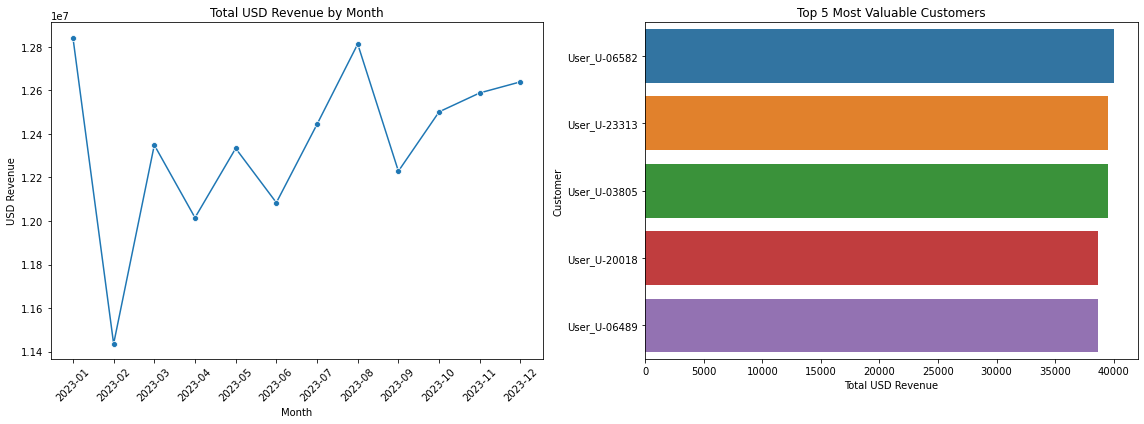

Month
2023-01    1.284176e+07
2023-02    1.143613e+07
2023-03    1.234893e+07
2023-04    1.201538e+07
2023-05    1.233364e+07
2023-06    1.208436e+07
2023-07    1.244416e+07
2023-08    1.281273e+07
2023-09    1.222895e+07
2023-10    1.250133e+07
2023-11    1.258822e+07
2023-12    1.263902e+07
Name: USD_Revenue, dtype: float64
   User_ID          name   USD_Revenue
0  U-06582  User_U-06582  40050.988262
1  U-23313  User_U-23313  39555.806629
2  U-03805  User_U-03805  39529.945085
3  U-20018  User_U-20018  38649.965242
4  U-06489  User_U-06489  38629.142146


In [8]:
df_final['Month'] = df_final['Date'].dt.to_period('M').astype(str)


monthly_revenue = df_final.groupby('Month')['USD_Revenue'].sum().sort_index()


top_customers = (
    df_final.groupby(['User_ID', 'name'])['USD_Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))


sns.lineplot(x=monthly_revenue.index, y=monthly_revenue.values, marker='o', ax=axes[0])
axes[0].set_title('Total USD Revenue by Month')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('USD Revenue')
axes[0].tick_params(axis='x', rotation=45)


sns.barplot(x='USD_Revenue', y='name', data=top_customers, ax=axes[1])
axes[1].set_title('Top 5 Most Valuable Customers')
axes[1].set_xlabel('Total USD Revenue')
axes[1].set_ylabel('Customer')

plt.tight_layout()
plt.show()

print(monthly_revenue)
print(top_customers)